# Installation

In [1]:
!pip3 install --upgrade matplotlib

     |████████████████████████████████| 11.2 MB 6.6 MB/s 
     |████████████████████████████████| 899 kB 48.9 MB/s 
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.2.2
    Uninstalling matplotlib-3.2.2:
      Successfully uninstalled matplotlib-3.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albumentations 0.1.12 requires imgaug<0.2.7,>=0.2.5, but you have imgaug 0.2.9 which is incompatible.


In [2]:
!pip install "qiskit[all]" 
# ==0.26.0
!pip install qiskit-optimization
!pip install cplex
!pip install pygsp
!pip install networkx
# !pip install dwave-ocean-sdk
!pip install pulp

!git clone https://github.com/loukasa/graph-coarsening.git && cd graph-coarsening && pip install .

     |████████████████████████████████| 6.5 MB 5.3 MB/s 
     |████████████████████████████████| 18.0 MB 354 kB/s 
     |████████████████████████████████| 240 kB 54.7 MB/s 
     |████████████████████████████████| 200 kB 56.6 MB/s 
     |████████████████████████████████| 154 kB 41.8 MB/s 
     |████████████████████████████████| 50 kB 7.8 MB/s 
     |████████████████████████████████| 118 kB 57.7 MB/s 
     |████████████████████████████████| 3.5 MB 42.2 MB/s 
     |████████████████████████████████| 294 kB 56.3 MB/s 
     |████████████████████████████████| 162 kB 55.5 MB/s 
     |████████████████████████████████| 54 kB 2.6 MB/s 
     |████████████████████████████████| 111 kB 42.6 MB/s 
     |████████████████████████████████| 1.6 MB 43.5 MB/s 
     |████████████████████████████████| 943 kB 55.0 MB/s 
     |████████████████████████████████| 49 kB 6.4 MB/s 
     |████████████████████████████████| 49 kB 4.8 MB/s 
     |████████████████████████████████| 37.5 MB 1.2 MB/s 
     |█████████████████

In [3]:
!pip install -Uqq ipdb
import ipdb

     |████████████████████████████████| 793 kB 6.1 MB/s 
     |████████████████████████████████| 381 kB 53.4 MB/s 
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-console 5.2.0 requires prompt-toolkit<2.0.0,>=1.0.0, but you have prompt-toolkit 3.0.29 which is incompatible.
google-colab 1.0.0 requires ipython~=5.5.0, but you have ipython 7.32.0 which is incompatible.
google-colab 1.0.0 requires requests~=2.23.0, but you have requests 2.27.1 which is incompatible.


In [4]:
%pdb on

Automatic pdb calling has been turned ON


# Code

## Import

In [5]:
# Load the packages that are required
import numpy as np
import pandas as pd
import operator, random
import networkx as nx
import matplotlib.pyplot as plt
import pulp as pl
import math

import sys

if sys.version_info < (3, 6):
    raise Exception("Please use Python version 3.6 or greater.")

try:
    import cplex
    from cplex.exceptions import CplexError
except:
    print("Warning: Cplex not found.")
import math

# Qiskit packages
from qiskit import BasicAer
from qiskit.quantum_info import Pauli
from qiskit.utils import QuantumInstance, algorithm_globals
from qiskit.algorithms import NumPyMinimumEigensolver, VQE
from qiskit.circuit.library import TwoLocal
from qiskit.algorithms.optimizers import SPSA

In [6]:
solver_list = pl.listSolvers(onlyAvailable=True)
solver_list

['CPLEX_PY', 'PULP_CBC_CMD']

## Instance Initializer

In [7]:
from pygsp import graphs


class Initializer:
    """Generate the coordenates of 'n' instances (nodes)"""
    
    def __init__(self, n):
        self.n = n

    def generate_instance(self):

        # Create NetworkX Graph
        G = nx.fast_gnp_random_graph(self.n, 0.75)

        # Populate NetworkX Graph with Random Weight
        for (u, v) in G.edges():
            G.edges[u,v]['weight'] = random.randint(1,10) / 10

        # Fetch NewtorkX Graph Adjacency Matrix
        W = nx.adjacency_matrix(G).todense()

        # Create PyGsp Graph
        G = graphs.Graph(W)

        # Initiate Coordinate From Weights
        G.set_coordinates()

        # Fetch Coordinates from PyGsp Graph
        xy = G.coords.T
        xc = xy[0]
        yc = xy[1]

        return xc, yc, W

# Initialize the problem by randomly generating the instance
initializer = Initializer(10)
xc, yc, instance = initializer.generate_instance()

len(xc), len(yc), instance.shape

(10, 10, (10, 10))

## Classical Optimizer

In [8]:
class ClassicalOptimizer:
    def __init__(self, instance, n, K):

        self.instance = instance
        self.n = n  # number of nodes
        self.K = K  # number of vehicles

    def compute_allowed_combinations(self):
        f = math.factorial
        return f(self.n) / f(self.K) / f(self.n - self.K)
    
    def ilp_model(self):
        """Uses pulp to return the definition of ILP problem"""
        #get the variable:
        n = self.n
        K = self.K
        instance = self.instance
        
        # Start the LP problem definition
        prob = pl.LpProblem("VRP", pl.LpMinimize)

        # define the decision variable
        dec_x = list(range(n ** 2))
        dec_u = list(range(dec_x[-1] + 1, dec_x[-1] + n))
        dec_total = dec_x + dec_u

        var_x = pl.LpVariable.dicts("x", dec_x, 0, 1, cat='Integer')
        var_u = pl.LpVariable.dicts("u", dec_u, 0.1, 1, cat="Continuous")

        # merge both dictionaries
        l = [var_x, var_u]
        dec_vars = {**l[0], **l[1]}

        # create the dictonary for the weights:
        my_obj = list(instance.reshape(1, n ** 2)[0]) + [0.0 for x in range(0, n - 1)]
        weight_opt = dict(zip(dec_vars, my_obj))

        # Define the Objective function
        prob += pl.lpSum([weight_opt[i]*dec_vars[i] for i in dec_total])
        
        # Define the Constrains      
        
        # create the array with all the right hand size contrainst values
        my_rhs = (
            2 * ([K] + [1 for x in range(0, n - 1)])
            + [1 - 0.1 for x in range(0, (n - 1) ** 2 - (n - 1))]
            + [0 for x in range(0, n)]
        )
        
        # subject to the node-visiting and the depot-visiting constraints:
        count = 0
        for ii in range(0, n):
            col = [x for x in range(0 + n * ii, n + n * ii)]
            prob += pl.lpSum([dec_vars[k] for k in col]) == my_rhs[count]
            count += 1

        for ii in range(0, n):
            col = [x for x in range(0 + ii, n ** 2, n)]
            prob += pl.lpSum([dec_vars[k] for k in col]) == my_rhs[count]
            count += 1

        # and the sub-tour elimination constraints:
        for ii in range(0, n):
            for jj in range(0, n):
                if (ii != jj) and (ii * jj > 0):
                    col = [ii + (jj * n), n ** 2 + ii - 1, n ** 2 + jj - 1]
                    coef = [1, 1, -1]
                    prob += pl.lpSum([co*dec_vars[k] for co, k in zip(coef,col)]) <= my_rhs[count]
                    count += 1
        
        # set the diagonal elements to zero , i=j
        for ii in range(0, n):
            col = [(ii) * (n + 1)]
            prob += pl.lpSum([dec_vars[k] for k in col]) == my_rhs[count]
            count += 1   
        
        return prob
    
    def gurobi_solution(self):
        prob = self.ilp_model()
        gap_rel = 0.01
        time_lim = 300 # time in seconds
        solver = pl.GUROBI_CMD(msg=1, gapRel=gap_rel, timeLimit=time_lim) 
        prob.solve(solver)
        print(f'"Status:", {pl.LpStatus[prob.status]}')
        if prob.status ==0:
            print(f'Not possible to find a solution with the tolerance {gap_rel} in {time_lim}s' )
            return
        elif prob.status ==1:
            obj = pl.value(prob.objective)
            print(f'The Objective function Value is: {round(obj,3)}') 

            solution = []
            solution_name = []
            for v in prob.variables():
                solution.append(v.varValue)
                solution_name.append(v.name)
                
            return(np.array(solution), obj, solution_name)
        else:
            print('Problem is infeasible')
            return
    
    def cbc_solution(self):
        prob = self.ilp_model()
        gap_rel = 0.01
        time_lim = 300 # time in seconds
        solver = pl.PULP_CBC_CMD(msg=1, gapRel=gap_rel, timeLimit=time_lim) 
        prob.solve(solver)
        print(f'"Status:", {pl.LpStatus[prob.status]}')
        
        if prob.status ==0:
            print(f'Not possible to find a solution with the tolerance {gap_rel} in {time_lim}s' )
            return
        elif prob.status ==1:
            obj = pl.value(prob.objective)
            print(f'The Objective function Value is: {round(obj,3)}') 

            solution = []
            solution_name = []
            for v in prob.variables():
                solution.append(v.varValue)
                solution_name.append(v.name)
            return(np.array(solution), obj, solution_name)
        
        else:
            print('Problem is infeasible')
            return
    
    def cplex_solution(self):

        # refactoring
        instance = self.instance
        n = self.n
        K = self.K

        my_obj = list(instance.reshape(1, n ** 2)[0]) + [0.0 for x in range(0, n - 1)]
        my_ub = [1 for x in range(0, n ** 2 + n - 1)]
        my_lb = [0 for x in range(0, n ** 2)] + [0.1 for x in range(0, n - 1)]
        my_ctype = "".join(["I" for x in range(0, n ** 2)]) + "".join(
            ["C" for x in range(0, n - 1)]
        )

        my_rhs = (
            2 * ([K] + [1 for x in range(0, n - 1)])
            + [1 - 0.1 for x in range(0, (n - 1) ** 2 - (n - 1))]
            + [0 for x in range(0, n)]
        )
        my_sense = (
            "".join(["E" for x in range(0, 2 * n)])
            + "".join(["L" for x in range(0, (n - 1) ** 2 - (n - 1))])
            + "".join(["E" for x in range(0, n)])
        )

        try:
            my_prob = cplex.Cplex()
            self.populatebyrow(my_prob, my_obj, my_ub, my_lb, my_ctype, my_sense, my_rhs)

            my_prob.solve()

        except CplexError as exc:
            print(exc)
            return

        x = my_prob.solution.get_values()
        x = np.array(x)
        cost = my_prob.solution.get_objective_value()

        return x, cost, my_sense
        my_prob = cplex.Cplex()
        return my_prob

    def populatebyrow(self, prob, my_obj, my_ub, my_lb, my_ctype, my_sense, my_rhs):

        n = self.n

        prob.objective.set_sense(prob.objective.sense.minimize)
        prob.variables.add(obj=my_obj, lb=my_lb, ub=my_ub, types=my_ctype)

        prob.set_log_stream(None)
        prob.set_error_stream(None)
        prob.set_warning_stream(None)
        prob.set_results_stream(None)

        rows = []
        for ii in range(0, n):
            col = [x for x in range(0 + n * ii, n + n * ii)]
            coef = [1 for x in range(0, n)]
            rows.append([col, coef])

        for ii in range(0, n):
            col = [x for x in range(0 + ii, n ** 2, n)]
            coef = [1 for x in range(0, n)]

            rows.append([col, coef])

        # Sub-tour elimination constraints:
        for ii in range(0, n):
            for jj in range(0, n):
                if (ii != jj) and (ii * jj > 0):

                    col = [ii + (jj * n), n ** 2 + ii - 1, n ** 2 + jj - 1]
                    coef = [1, 1, -1]

                    rows.append([col, coef])

        for ii in range(0, n):
            col = [(ii) * (n + 1)]
            coef = [1]
            rows.append([col, coef])

        prob.linear_constraints.add(lin_expr=rows, senses=my_sense, rhs=my_rhs)

## Coarsening

In [9]:
from pygsp import *
from pygsp import graphs
from graph_coarsening.coarsening_utils import *
import graph_coarsening.graph_utils

def coarsen(
    G,
    K=10,
    r=0.5,
    max_levels=10,
    method="variation_neighborhood",
    algorithm="greedy",
    Uk=None,
    lk=None,
    max_level_r=0.99,
    exclude = [0]
):
    """
    This function provides a common interface for coarsening algorithms that contract subgraphs

    Parameters
    ----------
    G : pygsp Graph
    K : int
        The size of the subspace we are interested in preserving.
    r : float between (0,1)
        The desired reduction defined as 1 - n/N.
    method : String
        ['variation_neighborhoods', 'variation_edges', 'variation_cliques', 'heavy_edge', 'algebraic_JC', 'affinity_GS', 'kron'] 
    
    Returns
    -------
    C : np.array of size n x N
        The coarsening matrix.
    Gc : pygsp Graph
        The smaller graph.
    Call : list of np.arrays
        Coarsening matrices for each level
    Gall : list of (n_levels+1) pygsp Graphs
        All graphs involved in the multilevel coarsening

    Example
    -------
    C, Gc, Call, Gall = coarsen(G, K=10, r=0.8)
    """
    r = np.clip(r, 0, 0.999)
    G0 = G
    N = G.N

    # current and target graph sizes
    n, n_target = N, np.ceil((1 - r) * N)

    C = sp.sparse.eye(N, format="csc")
    Gc = G

    Call, Gall = [], []
    Gall.append(G)

    g_coarsening_list = []
    g_iC = []

    for level in range(1, max_levels + 1):

        G = Gc

        # how much more we need to reduce the current graph
        r_cur = np.clip(1 - n_target / n, 0.0, max_level_r)

        if "variation" in method:

            if level == 1:
                if (Uk is not None) and (lk is not None) and (len(lk) >= K):
                    mask = lk < 1e-10
                    lk[mask] = 1
                    lsinv = lk ** (-0.5)
                    lsinv[mask] = 0
                    B = Uk[:, :K] @ np.diag(lsinv[:K])
                else:
                    offset = 2 * max(G.dw)
                    T = offset * sp.sparse.eye(G.N, format="csc") - G.L
                    lk, Uk = sp.sparse.linalg.eigsh(T, k=K, which="LM", tol=1e-5)
                    lk = (offset - lk)[::-1]
                    Uk = Uk[:, ::-1]
                    mask = lk < 1e-10
                    lk[mask] = 1
                    lsinv = lk ** (-0.5)
                    lsinv[mask] = 0
                    B = Uk @ np.diag(lsinv)
                A = B
            else:
                B = iC.dot(B)
                d, V = np.linalg.eig(B.T @ (G.L).dot(B))
                mask = d == 0
                d[mask] = 1
                dinvsqrt = d ** (-1 / 2)
                dinvsqrt[mask] = 0
                A = B @ np.diag(dinvsqrt) @ V

            if method == "variation_edges":
                coarsening_list = contract_variation_edges(
                    G, K=K, A=A, r=r_cur, algorithm=algorithm
                )
            else:
                coarsening_list = contract_variation_linear(
                    G, K=K, A=A, r=r_cur, mode=method
                )

        else:
            weights = get_proximity_measure(G, method, K=K)

            if algorithm == "optimal":
                # the edge-weight should be light at proximal edges
                weights = -weights
                if "rss" not in method:
                    weights -= min(weights)
                coarsening_list = matching_optimal(G, weights=weights, r=r_cur)

            elif algorithm == "greedy":
                coarsening_list = matching_greedy(G, weights=weights, r=r_cur)

        # Exclude Function
        flattend_coarsened_list = [ x for l in coarsening_list for x in l ]

        for ex in exclude:
            if ex in flattend_coarsened_list:
                (x, y) = np.where(coarsening_list[0:] == ex)
                coarsening_list = np.delete(coarsening_list, x, axis=0)


        g_coarsening_list += [coarsening_list]
        
        iC = get_coarsening_matrix(G, coarsening_list)
        g_iC += [iC]

        if iC.shape[1] - iC.shape[0] <= 2:
            break  # avoid too many levels for so few nodes

        C = iC.dot(C)
        Call.append(iC)

        Wc = graph_utils.zero_diag(coarsen_matrix(G.W, iC))  # coarsen and remove self-loops
        Wc = (Wc + Wc.T) / 2  # this is only needed to avoid pygsp complaining for tiny errors

        if not hasattr(G, "coords"):
            Gc = gsp.graphs.Graph(Wc)
        else:
            Gc = gsp.graphs.Graph(Wc, coords=coarsen_vector(G.coords, iC))
        Gall.append(Gc)

        n = Gc.N

        if n <= n_target:
            break

    return C, Gc, Call, Gall, g_iC, g_coarsening_list

## Route

In [10]:
def get_cmap(n, name='hsv'):
    '''Returns a function that maps each index in 0, 1, ..., n-1 to a distinct 
    RGB color; the keyword argument name must be a standard mpl colormap name.'''
    return plt.cm.get_cmap(name, n)

In [11]:
def edge_list2dict(edge_list):
    n1, n2, w = edge_list
    assert len(n1) == len(n2) == len(w)
    return { (n1[i], n2[i]):w[i] for i in range(len(n1)) }

def flatten(lst):
    return [ n for nlist in lst for n in nlist]

def edl2w(edl):
    nodes = set(flatten(list(edl.keys())))
    X =  len(nodes)
    A = np.zeros((X,X))
    for key, value in edl.items():
        n1, n2 = key

        # Set to weight 1 for the matrix
        A[n1, n2] = value
        A[n2, n1] = value
    return A

def get_distance(_from, _to, edl):
    return edl.get((_from, _to), edl.get((_to, _from), 0) )

def print_deconstructed_route(routes):
    for vehicle_route in routes:
        assert vehicle_route[0][0] == 0
        print(vehicle_route[0][0], end=' ')
        for route in vehicle_route:
            _from, _to = route
            print('-->', _to, end=' ')
        print()

def node_from_mapping(ix, mapping):
    if hasattr(mapping, 'toarray'):
        mapping = mapping.toarray()
    layout_data_c, layout_data_o = np.where(mapping > 0)
    return [ o for c, o in zip(layout_data_c, layout_data_o) if ix == c ]


def get_coarsen_distance_norm(coarsened_adjacency, mapping, parent_edl):
    adjacency = coarsened_adjacency.copy()
    shape = coarsened_adjacency.shape
    node_n = shape[0]
    for ix in range(node_n):
        for iy in range(node_n):
            # this is ix node to iy node
            n_x = node_from_mapping(ix, mapping)[0]
            n_y = node_from_mapping(iy, mapping)[0]
            distance = get_distance(n_x, n_y, parent_edl)
            adjacency[ix, iy] = distance
    return adjacency

In [12]:
class Route(object):
    def __init__(self, graph, depot=0, vehicles=2):

        # Keeping the raw data as well
        self._context = {
            'graph': graph
        }

        self.graph = graph.W.toarray()  # Adjacency Matrix
        self.n = self.graph.shape[0]    # Number of nodes
        self.depot = depot              # ID of the depot (default 0)
        self.cursor = depot             # Current location of the cursor vehicle
        self.vehicles = vehicles        # Number of vehicle
        
        self.coords = getattr(graph, 'coords', [])  # Coordinates of the nodes

        self.routes = None              # Calculated Routes

    def __call__(self, ):
        pass
    
    def solve(self, solver='cplex_solution'):
        classical_optimizer = ClassicalOptimizer(self.graph, self.n, self.vehicles)
        x, classical_cost, _ = getattr(classical_optimizer, solver)()
        return x, classical_cost

    def routine(self, reduction=0.2, method='nearest'):
        pass
    
    def compare_with(self, coarsened_route, mapping):
        pass

    def optimize_route(self, route):
        pass

    # Coarsens the graph and return a Route object based on the coarsened graph
    def coarsen(self, coarsening_ration=0.2, method='nearest') -> object:
        _graph = self.pygsp_graph()
        parent_edl = edge_list2dict(_graph.get_edge_list())

        # Coarsen the graph
        C, Gc, Call, Gall, g_iC, g_coarsening_list = coarsen(_graph, K=self.vehicles, r=coarsening_ration, method=method, max_levels=1) 
        metrics = coarsening_quality(_graph, C, kmax=kmax)

        assert len(Gall) > 1 # Check if coarsening was successful
        mapping  = g_iC[0]
        coarsened_adjacency = Gall[1].W.toarray()
        coarsened_adjacency_distance_norm = get_coarsen_distance_norm(coarsened_adjacency, mapping, parent_edl)
        coarsened_graph = graphs.Graph(coarsened_adjacency_distance_norm)

        _child_route = Route(Gall[1], self.depot, self.vehicles)

        self._context['coarsened_graph'] = self._context.get('coarsened_graph', {})
        self._context['coarsened_graph'][str(id(_child_route))] = _child_route
        
        return metrics, _child_route, mapping
    
    # Returns the source graph PyGSP object
    def pygsp_graph(self, ):
        return self._context['graph']

    # After solving the Linear Program, it is needed to extract the routes from the solution
    def load_routes(self, x, verbose=0):
        self.routes = []

        _chain = []
        _k = self.n*self.n

        # travel_metrices = x[0:_k].reshape((self.n, self.n))
        # for ix in range(0, self.n):
        #     for iy in range(0, self.n):
        #         if travel_metrices[ix][iy] == 1:
        #             if (ix, iy) not in _chain and ix != iy:
        #                 _chain += [(ix, iy)]
        
        # travel_metrices = x[len(x) - _k:].reshape((self.n, self.n))
        travel_metrices = x
        
        for ii in range(0, len(travel_metrices)):
            ix = ii // self.n
            iy = ii % self.n
            if travel_metrices[ii] > 0:
                if (ix, iy) not in _chain and ix != iy:
                    _chain += [(ix, iy)]
        
        for vehicle in range(self.vehicles):
            cur = self.depot
            route = []
            travel = True
            if verbose: print(f"{cur}", end='  ')
            while travel:
                element = [(_from, _to) for (_from, _to) in _chain if _from == cur]
                # if len(element) == 0:
                #     element = [(_to, _from) for (_from, _to) in _chain if _to == cur]
                (_from, _to) = element[vehicle] if len(element) > 1 else element[0]
                cur = _to
                route += [(_from, _to)]
                if verbose: print(f"->  {_to}", end='  ')

                if cur == self.depot:
                    travel = False
            
            self.routes += [route]
            if verbose: print()

        # Check if all vehicles are accounted for, while calcultaing the routes
        assert len(self.routes) == self.vehicles

        return self.routes
    
    # Inflate a coarsened graph with respect to parent graph
    def inflate_route(self, coarsen_map, child_edl, vehicle = 0):
        pass

    # Normalize an inflated graph
    def normalize(self, inflated_route, parent_edl):
        pass

    def cost(self, route):
        _graph = self.pygsp_graph()
        edl = edge_list2dict(_graph.get_edge_list())

        cost = 0
        for (_from, _to) in route:
            cost += edl.get((_from, _to), edl.get((_to, _from)) )
        return cost
    
    def visualize_route(self, graph, routes, coords, colormap='hsv'):
        [xc, yc] = coords
        plt.figure()
        plt.scatter(xc, yc, s=200)
        # for i in range(len(xc)):
        #     plt.annotate(i, (xc[i] + 0.15, yc[i]), size=16, color="r")

        i = 0
        for x, y in zip(xc, yc):
            plt.annotate(i, (x + 0.075, y), size=16, color="r")
            i += 1
        
        plt.plot(xc[0], yc[0], "r*", ms=20)

        plt.grid()

        vehicle_cmap = get_cmap(len(routes) + 1, name=colormap)
        print('colors : ', len(routes))
        for vehicle in range(len(routes)):
            tour = routes[vehicle]
            color = vehicle_cmap(vehicle)
            for hop in tour:
                _from, _to = hop

                plt.arrow(
                    xc[_from],
                    yc[_from],
                    xc[_to] - xc[_from],
                    yc[_to] - yc[_from],
                    length_includes_head=True,
                    head_width=0.05,
                    color = color
                )

        plt.show()
        return plt


## Test

In [13]:
# Parameters

# Initialize the problem by defining the parameters
n = 17  # number of nodes + depot (n+1)
K = 3   # number of vehicles
r = 0.3 # the extend of dimensionality reduction (r=0 means no reduction)

k = 2     # The size of the subspace we are interested in preserving
kmax = 25 # Until which eigenvalue we are interested in

In [14]:
# Creating the graph

# Initialize the problem by randomly generating the instance
initializer = Initializer(n)
xc, yc, instance = initializer.generate_instance()

# Define Graph
graph = graphs.Graph(instance)
method = 'nearest' # 'optimal' # 'greedy' # 'nearest'  

coords = np.array([xc, yc]).reshape((len(xc), 2))
graph.set_coordinates(coords)

In [15]:
route = Route(graph, vehicles=K)
# route.solve('cplex_solution')
# route.solve('cbc_solution')

x, cost = route.solve('cplex_solution')
cost

0.0

In [84]:
x

array([ 0. , -0. ,  1. , -0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. ,
        0. , -0. , -0. ,  1. , -0. ,  1. , -0. ,  0. , -0. ,  0. ,  0. ,
       -0. , -0. , -0. , -0. , -0. ,  0. , -0. ,  1. ,  0. , -0. , -0. ,
       -0. ,  1. , -0. ,  0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0. ,  0. , -0. , -0. , -0. ,  0. ,  0. ,  0. ,
       -0. ,  0. ,  0. , -0. , -0. ,  1. , -0. ,  0. , -0. , -0. , -0. ,
       -0. ,  0. ,  1. ,  0. , -0. , -0. ,  0. , -0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0. ,  0. , -0. ,  0. , -0. , -0. , -0. , -0. ,
        0. , -0. ,  0. ,  0. ,  0. ,  1. , -0. , -0. , -0. , -0. , -0. ,
       -0. ,  0. , -0. , -0. , -0. , -0. ,  0. , -0. ,  0. ,  0. ,  1. ,
        0. , -0. , -0. , -0. , -0. ,  0. , -0. , -0. , -0. , -0. , -0. ,
       -0. , -0. , -0. ,  0. ,  0. ,  0. , -0. , -0. , -0. ,  1. ,  0. ,
       -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,  0. ,  1. ,
       -0. ,  0. , -0. ,  0. , -0. ,  0. , -0. , -0

In [85]:
routes = route.load_routes(x)
routes

[[(0, 2), (2, 0)],
 [(0, 14),
  (14, 10),
  (10, 1),
  (1, 12),
  (12, 15),
  (15, 5),
  (5, 8),
  (8, 6),
  (6, 7),
  (7, 11),
  (11, 0)],
 [(0, 16), (16, 3), (3, 9), (9, 13), (13, 4), (4, 0)]]

colors :  3


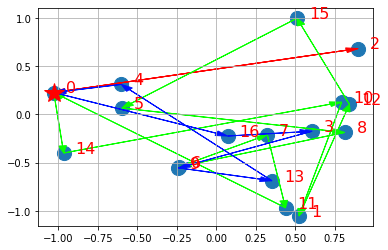

<module 'matplotlib.pylab' from '/usr/local/lib/python3.7/dist-packages/matplotlib/pylab.py'>

In [86]:
route.visualize_route(route.pygsp_graph(), routes, route.coords.T, colormap='hsv')